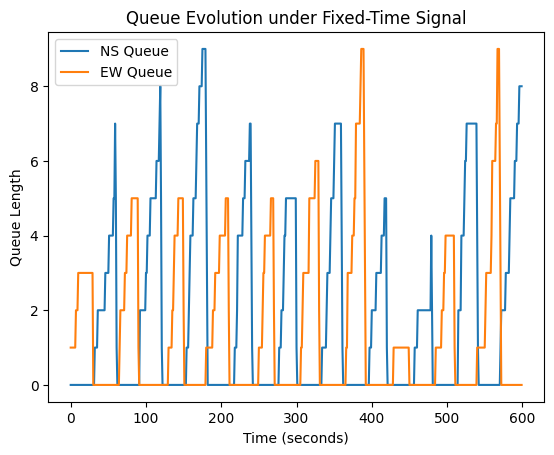

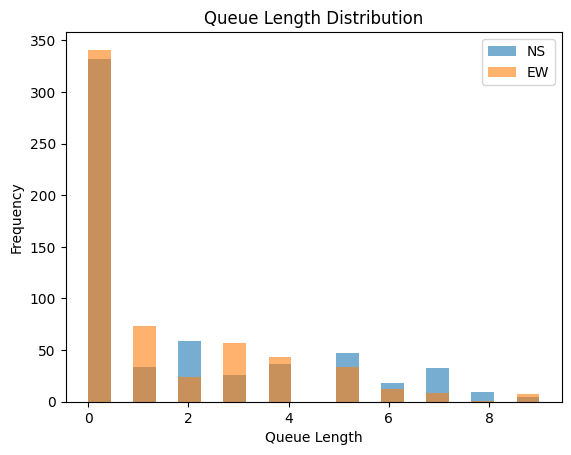

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 600
dt = 1

lambda_NS = 0.25
lambda_EW = 0.2

mu_speed = 40
sigma_speed = 8

gNS = 30
gEW = 30
cycle = gNS + gEW

queue_NS = 0
queue_EW = 0

q_ns_hist = []
q_ew_hist = []

wait_NS = []
wait_EW = []

for t in range(T):

    arrivals_NS = np.random.poisson(lambda_NS*dt)
    arrivals_EW = np.random.poisson(lambda_EW*dt)

    queue_NS += arrivals_NS
    queue_EW += arrivals_EW

    phase = t % cycle

    speed_sample = np.random.normal(mu_speed, sigma_speed, 10)
    service_rate = max(1, int(np.mean(speed_sample)/10))

    if phase < gNS:
        depart = min(queue_NS, service_rate)
        queue_NS -= depart
        wait_NS.extend([t]*depart)

    else:
        depart = min(queue_EW, service_rate)
        queue_EW -= depart
        wait_EW.extend([t]*depart)

    q_ns_hist.append(queue_NS)
    q_ew_hist.append(queue_EW)


plt.figure()
plt.plot(q_ns_hist,label="NS Queue")
plt.plot(q_ew_hist,label="EW Queue")
plt.xlabel("Time (seconds)")
plt.ylabel("Queue Length")
plt.title("Queue Evolution under Fixed-Time Signal")
plt.legend()
plt.show()


plt.figure()
plt.hist(q_ns_hist,bins=20,alpha=0.6,label="NS")
plt.hist(q_ew_hist,bins=20,alpha=0.6,label="EW")
plt.xlabel("Queue Length")
plt.ylabel("Frequency")
plt.title("Queue Length Distribution")
plt.legend()
plt.show()

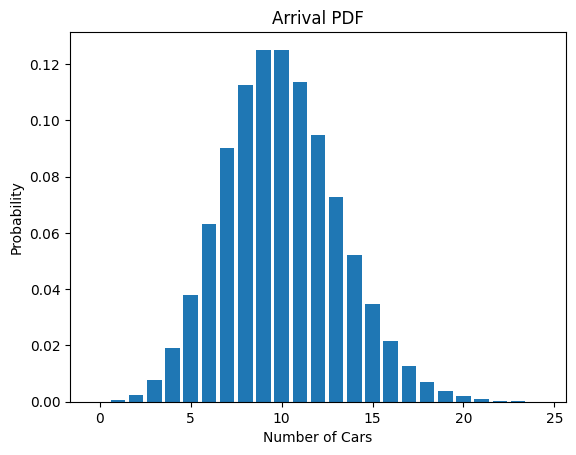

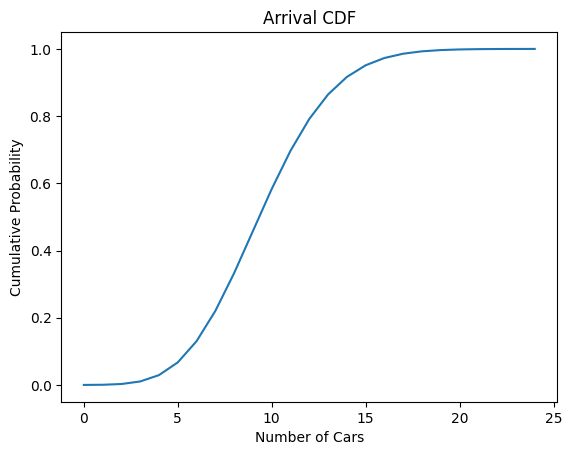

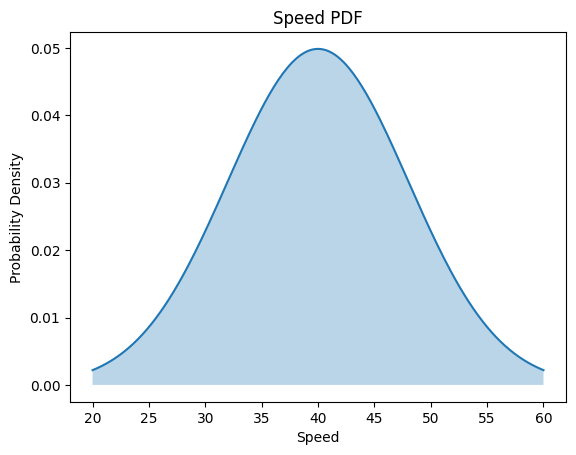

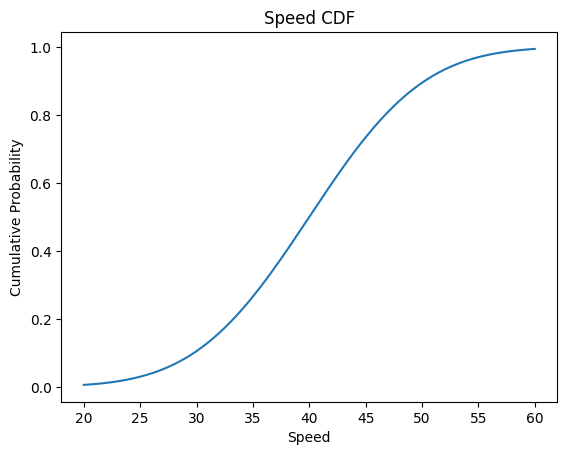

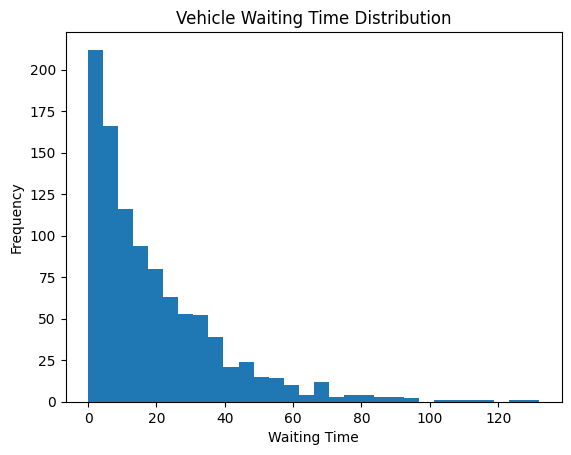

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

np.random.seed(10)

lambda_rate = 10
cars = np.arange(0,25)

arrival_pdf = poisson.pmf(cars, lambda_rate)
arrival_cdf = poisson.cdf(cars, lambda_rate)

speeds = np.linspace(20,60,200)
mu = 40
sigma = 8

speed_pdf = norm.pdf(speeds,mu,sigma)
speed_cdf = norm.cdf(speeds,mu,sigma)


plt.figure()
plt.bar(cars,arrival_pdf)
plt.xlabel("Number of Cars")
plt.ylabel("Probability")
plt.title("Arrival PDF")
plt.show()


plt.figure()
plt.plot(cars,arrival_cdf)
plt.xlabel("Number of Cars")
plt.ylabel("Cumulative Probability")
plt.title("Arrival CDF")
plt.show()


plt.figure()
plt.plot(speeds,speed_pdf)
plt.fill_between(speeds,speed_pdf,alpha=0.3)
plt.xlabel("Speed")
plt.ylabel("Probability Density")
plt.title("Speed PDF")
plt.show()


plt.figure()
plt.plot(speeds,speed_cdf)
plt.xlabel("Speed")
plt.ylabel("Cumulative Probability")
plt.title("Speed CDF")
plt.show()


wait_times = np.random.exponential(20,1000)

plt.figure()
plt.hist(wait_times,bins=30)
plt.xlabel("Waiting Time")
plt.ylabel("Frequency")
plt.title("Vehicle Waiting Time Distribution")
plt.show()